In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

from pathlib import Path

In [ ]:
# define your custom path
path_to_pypsa_zm = "."
networks_path = Path(path_to_pypsa_zm, "pypsa-zambia/networks/linetypes_test_v2")

run_id = "Global default base_voltage, "

In [3]:
n_fl_presolv = "elec_s_10_ec_lv1.0_Co2L-3h.nc"
n_fl_s = "elec_s.nc"
n_fl_elec = "elec.nc"

## Load networks

In [4]:
n_presolv = pypsa.Network(Path(networks_path, n_fl_presolv))
n_s = pypsa.Network(Path(networks_path, n_fl_s))
n_elec = pypsa.Network(Path(networks_path, n_fl_elec))

INFO:pypsa.io:Imported network elec_s_10_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, line_types, loads, storage_units, transformers


## Scan through linetypes

In [5]:
[
    n_elec.lines.type.unique(),
    n_s.lines.type.unique(),
    n_presolv.lines.type.unique()
]

[array(['ACSR Bison 330.0', 'ACSR Panther 132.0', 'ACSR Zebra 220.0',
        'ACSR Wolf 66.0'], dtype=object),
 array(['Al/St 240/40 4-bundle 380.0'], dtype=object),
 array(['Al/St 240/40 4-bundle 380.0'], dtype=object)]

In [6]:
[
    n_elec.lines.v_nom.unique(),
    n_s.lines.v_nom.unique(),
    n_presolv.lines.v_nom.unique()
]

[array([330., 132., 220.,  66.,  88., 120.]), array([380.]), array([380.])]

In [7]:
[
    n_elec.line_types.index,
    n_s.line_types.index,
    n_presolv.line_types.index
]

[Index(['149-AL1/24-ST1A 10.0', '149-AL1/24-ST1A 110.0', '149-AL1/24-ST1A 20.0',
        '15-AL1/3-ST1A 0.4', '184-AL1/30-ST1A 110.0', '184-AL1/30-ST1A 20.0',
        '24-AL1/4-ST1A 0.4', '243-AL1/39-ST1A 110.0', '243-AL1/39-ST1A 20.0',
        '305-AL1/39-ST1A 110.0', '48-AL1/8-ST1A 0.4', '48-AL1/8-ST1A 10.0',
        '48-AL1/8-ST1A 20.0', '490-AL1/64-ST1A 220.0', '490-AL1/64-ST1A 380.0',
        '94-AL1/15-ST1A 0.4', '94-AL1/15-ST1A 10.0', '94-AL1/15-ST1A 20.0',
        'N2XS(FL)2Y 1x120 RM/35 64/110 kV', 'N2XS(FL)2Y 1x185 RM/35 64/110 kV',
        'N2XS(FL)2Y 1x240 RM/35 64/110 kV', 'N2XS(FL)2Y 1x300 RM/35 64/110 kV',
        'NA2XS2Y 1x185 RM/25 12/20 kV', 'NA2XS2Y 1x240 RM/25 12/20 kV',
        'NA2XS2Y 1x95 RM/25 12/20 kV', 'NAYY 4x120 SE', 'NAYY 4x150 SE',
        'NAYY 4x50 SE', 'Al/St 240/40 2-bundle 220.0',
        'Al/St 240/40 3-bundle 300.0', 'Al/St 240/40 4-bundle 380.0',
        'Al/St 490/64 4-bundle 380.0', 'Al/St 560/50 4-bundle 750.0',
        'HVDC XLPE 1000', 'HVDC

## Exploration of grid model

### Plotting definitions

In [8]:
def plot_annot_n(n, ax, param="s_nom"):
    """
    Annotate by properties defined through line dataframe
    """    
    n.plot(
        ax=ax,
        line_alpha=0.5,
        bus_alpha=0.5,
    )

    for line_name, line in n.lines.iterrows():
        bus0 = n.buses.loc[line.bus0]
        bus1 = n.buses.loc[line.bus1]

        x = (bus0.x + bus1.x) / 2
        y = (bus0.y + bus1.y) / 2

        ax.text(
            x,
            y,
            #f"{line.s_nom:.0f}",
            f"{line[param]:.2f}",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=8,
        )

In [9]:
def plot_annot_n_by_linetypes(n, ax, linetype_param="c_per_length"):
    """
    Annotate by properties defined through linetypes
    """
    n.plot(
        ax=ax,
        line_alpha=0.5,
        bus_alpha=0.5,
    )

    line_param = (
        n.lines["type"].map(n.line_types[linetype_param])
        * n.lines["length"]
        * n.lines["num_parallel"]
    )

    for line_name, line in n.lines.iterrows():
        bus0 = n.buses.loc[line.bus0]
        bus1 = n.buses.loc[line.bus1]

        x = (bus0.x + bus1.x) / 2
        y = (bus0.y + bus1.y) / 2

        ax.text(
            x,
            y,
            f"{line_param.loc[line_name]:.2f}",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=8,
        )

### Grid Exploration

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


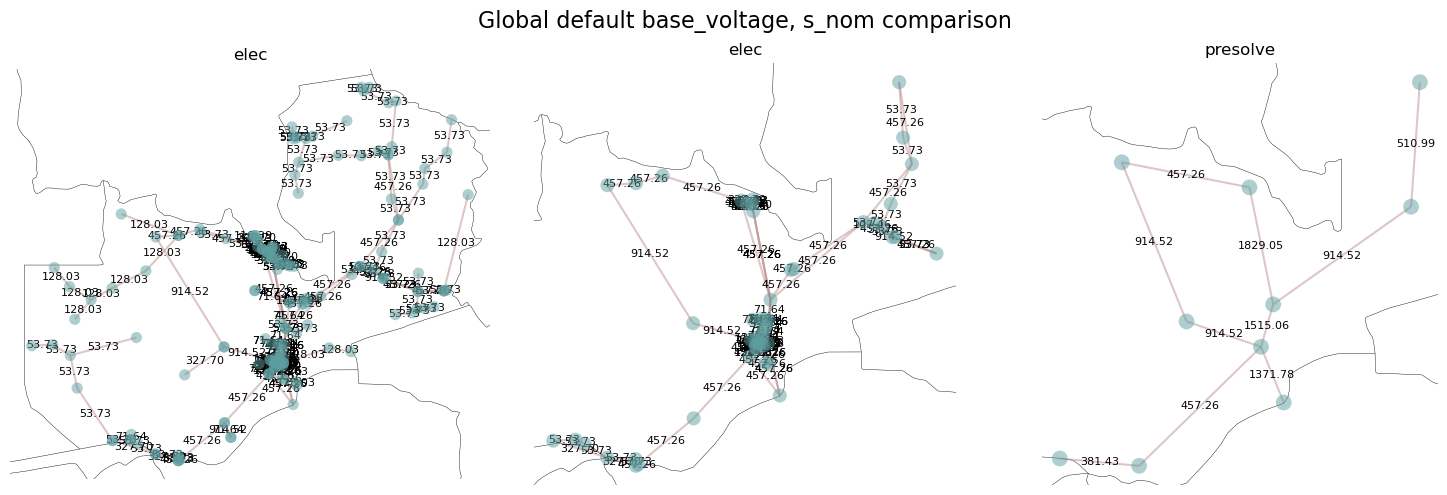

In [10]:
run_id = "Global default base_voltage, "
param_to_plot = "s_nom"
title_line = run_id + param_to_plot + " comparison"

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_annot_n(n_elec, axes[0], param=param_to_plot)
plot_annot_n(n_s, axes[1], param=param_to_plot)
plot_annot_n(n_presolv, axes[2], param=param_to_plot)

axes[0].set_title("elec")
axes[1].set_title("elec")
axes[2].set_title("presolve")

fig.suptitle(title_line, fontsize=16)

plt.tight_layout()
plt.show()

Number of parallel circuits is used as an empiric parameter during simplification.

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


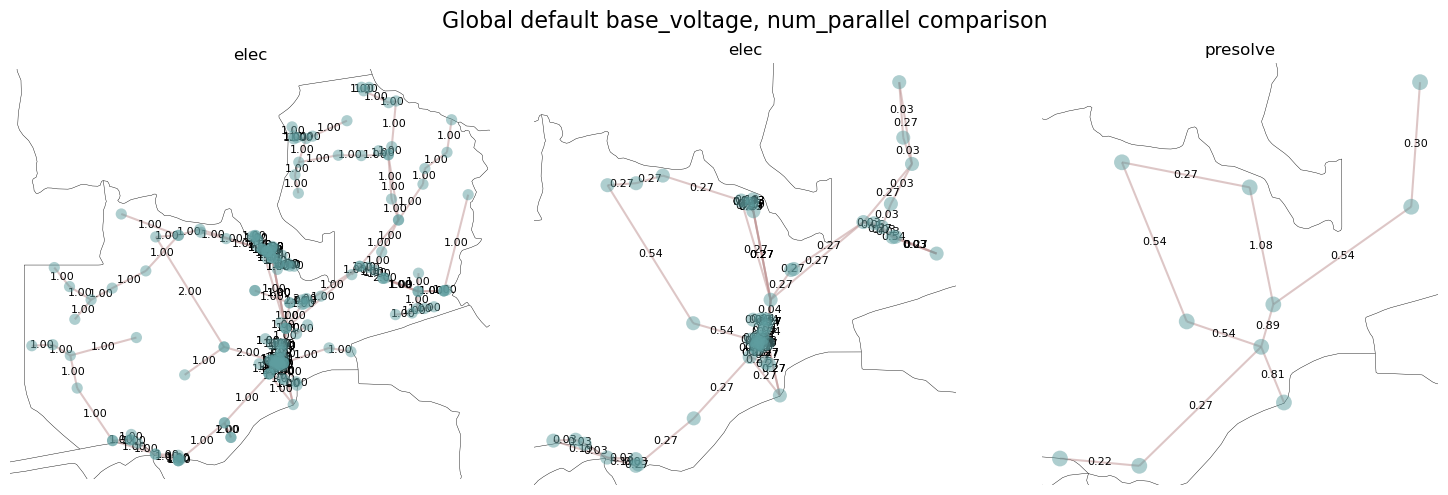

In [11]:
run_id = "Global default base_voltage, "
param_to_plot = "num_parallel"
title_line = run_id + param_to_plot + " comparison"

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_annot_n(n_elec, axes[0], param=param_to_plot)
plot_annot_n(n_s, axes[1], param=param_to_plot)
plot_annot_n(n_presolv, axes[2], param=param_to_plot)

axes[0].set_title("elec")
axes[1].set_title("elec")
axes[2].set_title("presolve")

fig.suptitle(title_line, fontsize=16)

plt.tight_layout()
plt.show()

Electrical properties of lines are taken from line types information, not from `n.line` dataframe.

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


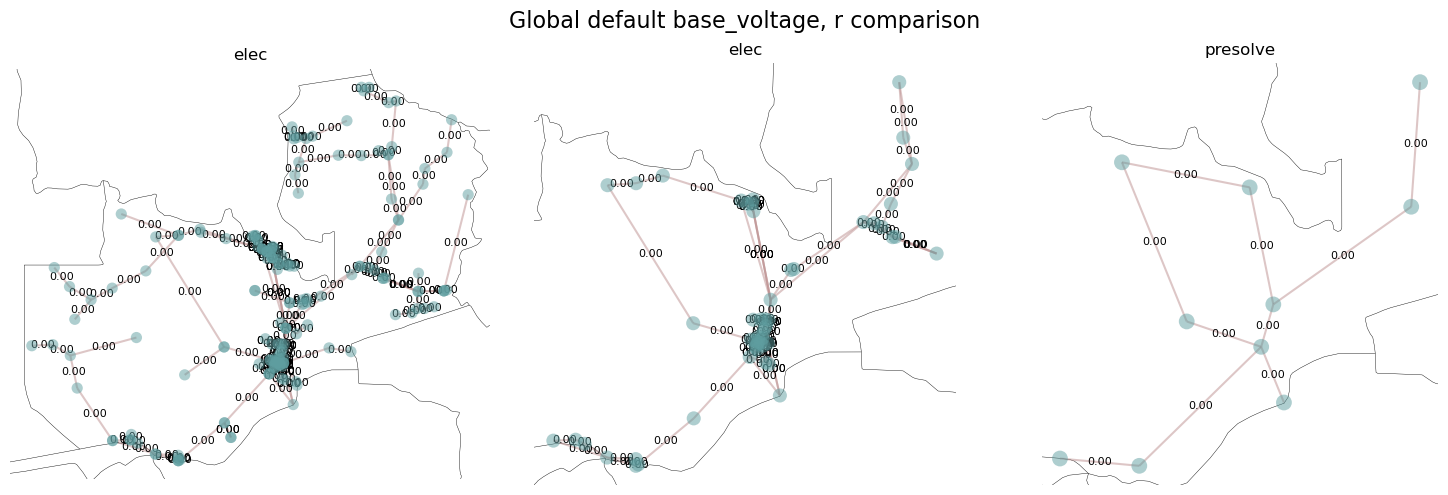

In [12]:
param_to_plot = "r"
title_line = run_id + param_to_plot + " comparison"

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_annot_n(n_elec, axes[0], param=param_to_plot)
plot_annot_n(n_s, axes[1], param=param_to_plot)
plot_annot_n(n_presolv, axes[2], param=param_to_plot)

axes[0].set_title("elec")
axes[1].set_title("elec")
axes[2].set_title("presolve")

fig.suptitle(title_line, fontsize=16)

plt.tight_layout()
plt.show()

In [13]:
[
    n_presolv.lines["x"].unique(),
    n_presolv.lines["r"].unique(),
    n_presolv.lines["b"].unique(),
    n_presolv.lines["g"].unique(),    
]

[array([0.]), array([0.]), array([0.]), array([0.])]

To get meaningful values of electric parameters, they must be extracted from linetypes. Such a procedure is implemented in `plot_annot_n_by_linetypes` with 
```    line_param = (
        n.lines["type"].map(n.line_types[linetype_param])
        * n.lines["length"]
        * n.lines["num_parallel"]
    )
```

Using that, we obtain meaningful values for electrical parameters across branches of the network.

~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


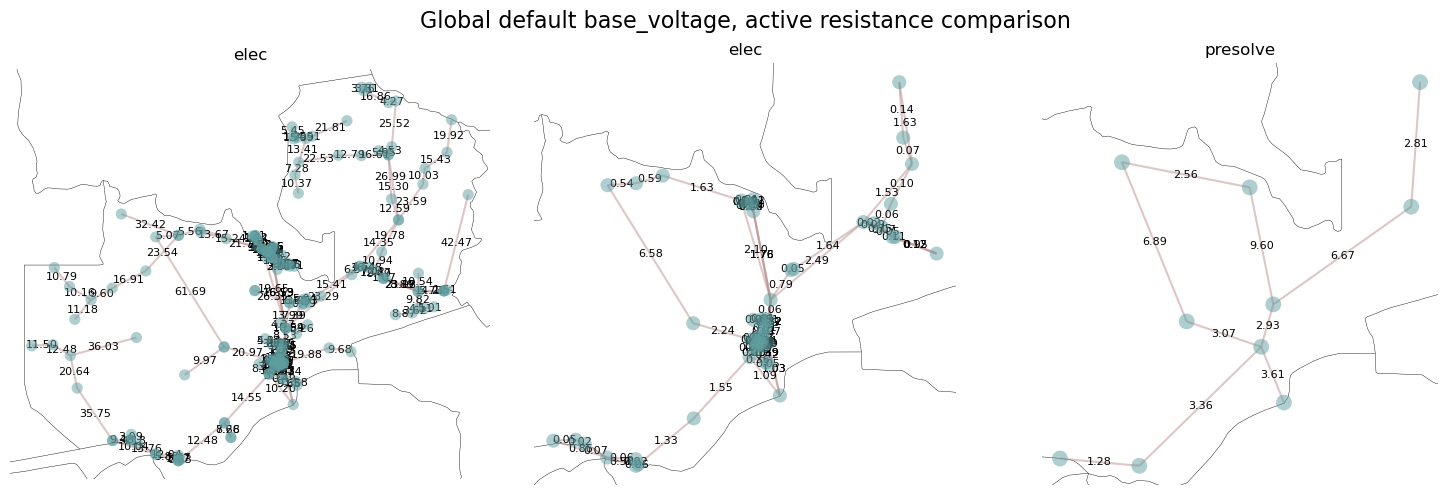

In [14]:
run_id = "Global default base_voltage, "
param_to_extract = "r_per_length"
param_to_plot = "active resistance"
title_line = run_id + param_to_plot + " comparison"

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

plot_annot_n_by_linetypes(n_elec, axes[0], linetype_param=param_to_extract)
plot_annot_n_by_linetypes(n_s, axes[1], linetype_param=param_to_extract)
plot_annot_n_by_linetypes(n_presolv, axes[2], linetype_param=param_to_extract)

axes[0].set_title("elec")
axes[1].set_title("elec")
axes[2].set_title("presolve")

fig.suptitle(title_line, fontsize=16)

plt.tight_layout()
plt.show()